In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Data download
data = yf.download("BTC-USD", period="5y")

C:\Users\Tirupati\AppData\Local\Temp\ipykernel_14244\570908832.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("BTC-USD", period="5y")
[*********************100%***********************]  1 of 1 completed


In [4]:
print(data.head())

Price              Close          High           Low          Open  \
Ticker           BTC-USD       BTC-USD       BTC-USD       BTC-USD   
Date                                                                 
2021-03-30  58917.691406  59447.222656  57251.550781  57750.132812   
2021-03-31  58918.832031  59930.027344  57726.417969  58930.277344   
2021-04-01  59095.808594  59586.070312  58505.277344  58926.562500   
2021-04-02  59384.312500  60267.187500  58869.281250  59098.878906   
2021-04-03  57603.890625  60110.269531  57603.890625  59397.410156   

Price            Volume  
Ticker          BTC-USD  
Date                     
2021-03-30  54414116432  
2021-03-31  65520826225  
2021-04-01  61669163792  
2021-04-02  58727860620  
2021-04-03  59641344484  


In [5]:
print(data.columns)

MultiIndex([( 'Close', 'BTC-USD'),
            (  'High', 'BTC-USD'),
            (   'Low', 'BTC-USD'),
            (  'Open', 'BTC-USD'),
            ('Volume', 'BTC-USD')],
           names=['Price', 'Ticker'])


In [6]:
print(data.isnull().sum())

Price   Ticker 
Close   BTC-USD    0
High    BTC-USD    0
Low     BTC-USD    0
Open    BTC-USD    0
Volume  BTC-USD    0
dtype: int64


In [7]:
# Flatten columns (IMPORTANT)
data.columns = data.columns.droplevel(1)

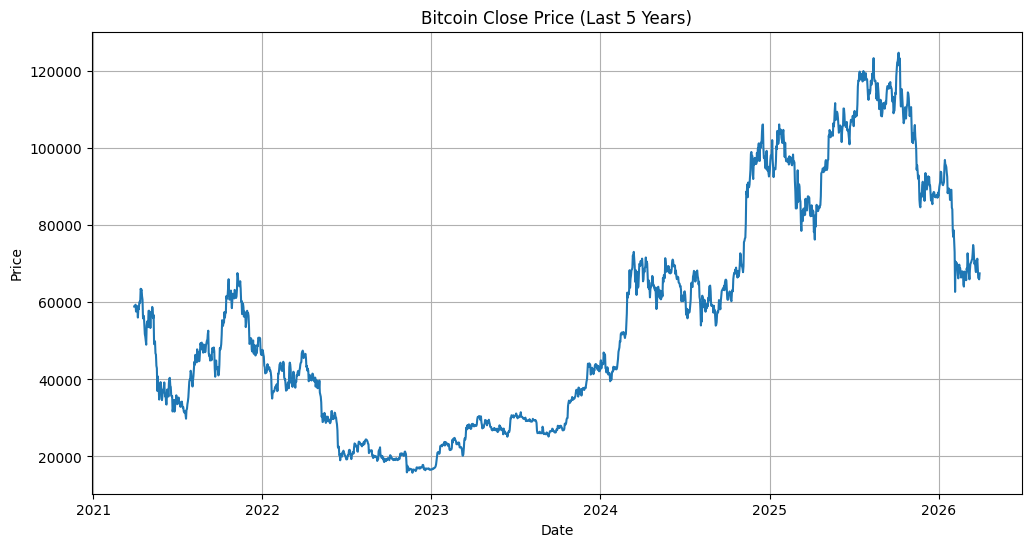

In [8]:
btc = data['Close']

# Plot
plt.figure(figsize=(12,6))
plt.plot(btc)
plt.title("Bitcoin Close Price (Last 5 Years)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid()
plt.show()

In [9]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(btc)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -1.1985541349525715
p-value: 0.6742173770926008


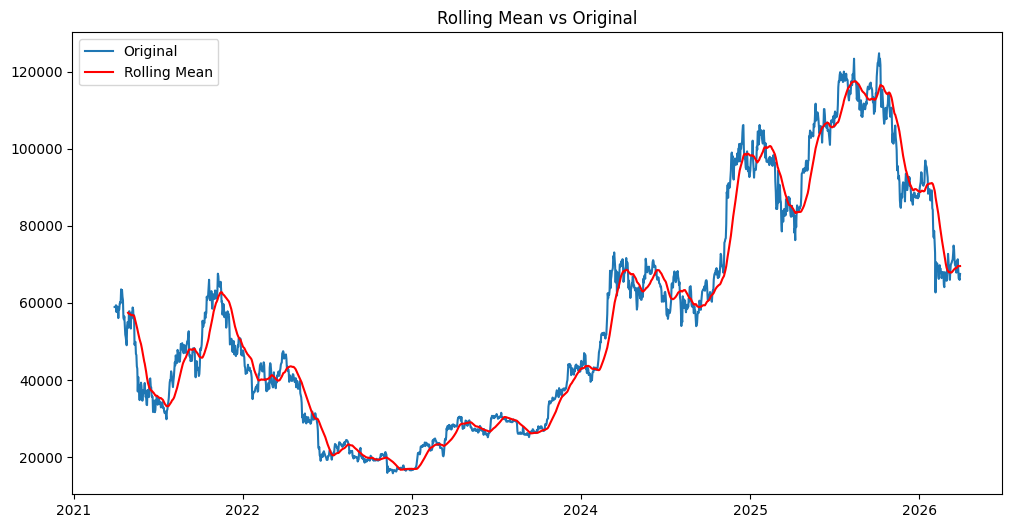

In [10]:
rolling_mean = btc.rolling(window=30).mean()

plt.figure(figsize=(12,6))
plt.plot(btc, label="Original")
plt.plot(rolling_mean, label="Rolling Mean", color='red')
plt.legend()
plt.title("Rolling Mean vs Original")
plt.show()

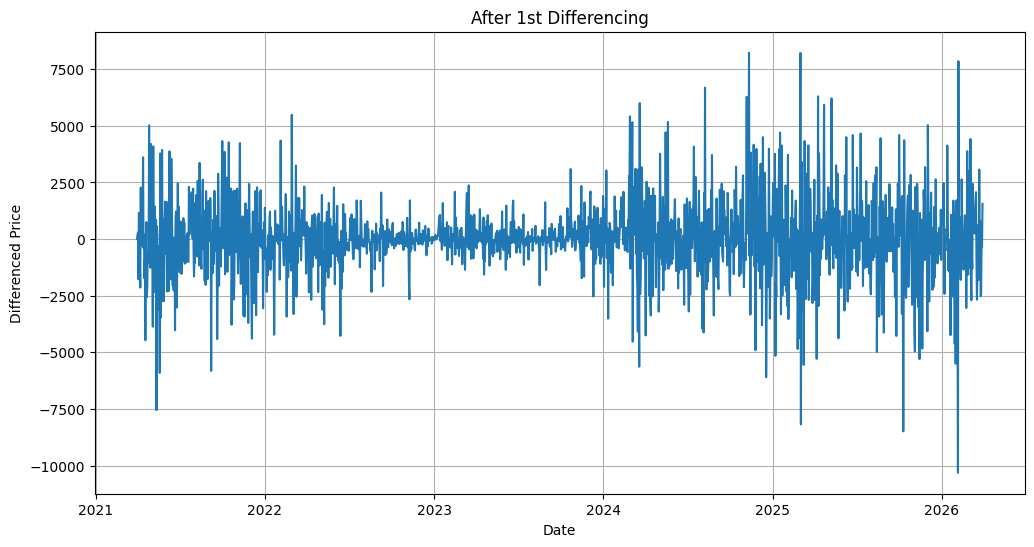

In [11]:
btc_diff = btc.diff().dropna()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(btc_diff)
plt.title("After 1st Differencing")
plt.xlabel("Date")
plt.ylabel("Differenced Price")
plt.grid()
plt.show()

In [12]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(btc_diff)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -7.984137138787355
p-value: 2.5759727517461285e-12


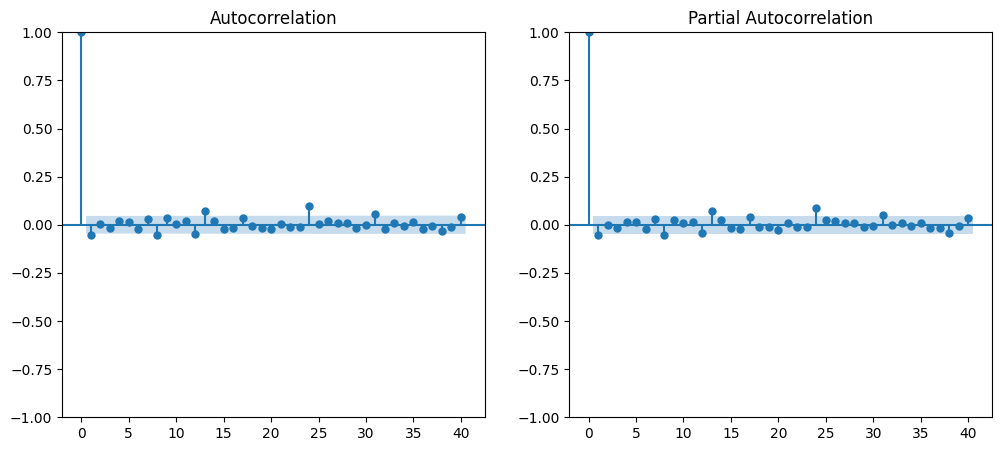

In [13]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(12,5))

# ACF
plt.subplot(1,2,1)
plot_acf(btc_diff, ax=plt.gca(), lags=40)

# PACF
plt.subplot(1,2,2)
plot_pacf(btc_diff, ax=plt.gca(), lags=40)

plt.show()

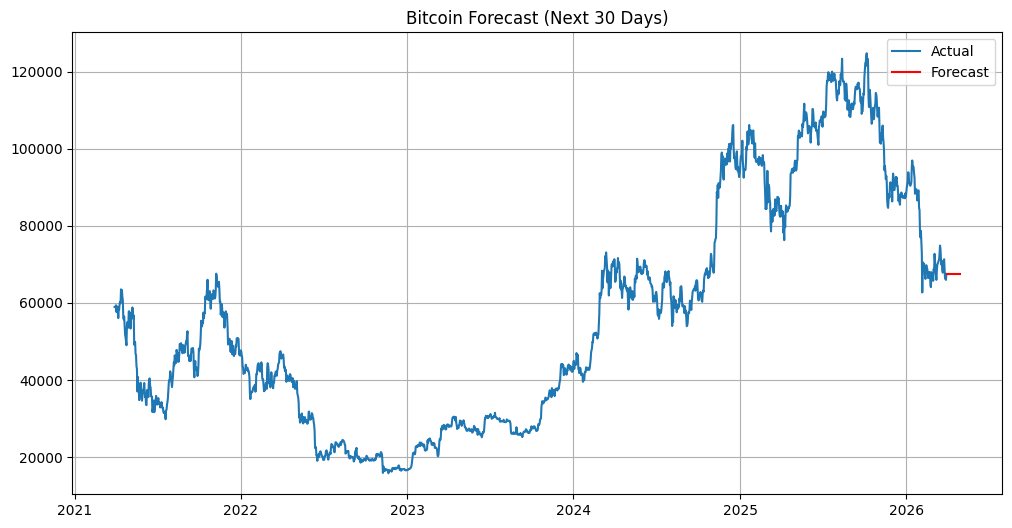

In [22]:
plt.figure(figsize=(12,6))

# Original data
plt.plot(btc, label="Actual")

# Forecast
plt.plot(forecast, label="Forecast", color='red')

plt.title("Bitcoin Forecast (Next 30 Days)")
plt.legend()
plt.grid()
plt.show()

In [23]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(btc,
                order=(0,1,0),
                seasonal_order=(1,1,1,7))

model_fit = model.fit()

forecast = model_fit.forecast(steps=30)

C:\Users\Tirupati\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Tirupati\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


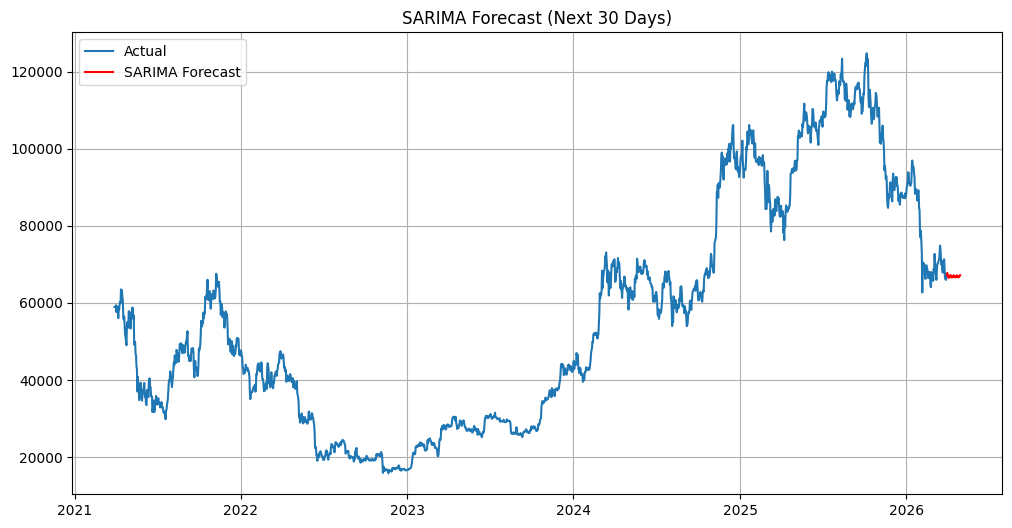

In [24]:
plt.figure(figsize=(12,6))

plt.plot(btc, label="Actual")
plt.plot(forecast, label="SARIMA Forecast", color='red')

plt.title("SARIMA Forecast (Next 30 Days)")
plt.legend()
plt.grid()
plt.show()

In [25]:
from pmdarima import auto_arima

auto_model = auto_arima(
    btc,
    seasonal=True,
    m=7,              # weekly seasonality
    trace=True,       # process show karega
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=32210.425, Time=2.03 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=32204.679, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=32204.405, Time=0.24 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=32204.443, Time=0.22 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=32202.694, Time=0.02 sec
 ARIMA(0,1,0)(1,0,0)[7] intercept   : AIC=32206.047, Time=0.15 sec
 ARIMA(0,1,0)(0,0,1)[7] intercept   : AIC=32206.092, Time=0.15 sec
 ARIMA(0,1,0)(1,0,1)[7] intercept   : AIC=32206.081, Time=0.65 sec
 ARIMA(1,1,0)(0,0,0)[7] intercept   : AIC=32202.844, Time=0.08 sec
 ARIMA(0,1,1)(0,0,0)[7] intercept   : AIC=32202.854, Time=0.09 sec
 ARIMA(1,1,1)(0,0,0)[7] intercept   : AIC=32204.843, Time=0.26 sec

Best model:  ARIMA(0,1,0)(0,0,0)[7]          
Total fit time: 3.952 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:       

In [32]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(btc,
                order=(0,1,0),
                seasonal_order=(0,1,0,7))

model_fit = model.fit()

forecast = model_fit.forecast(steps=30)

C:\Users\Tirupati\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Tirupati\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


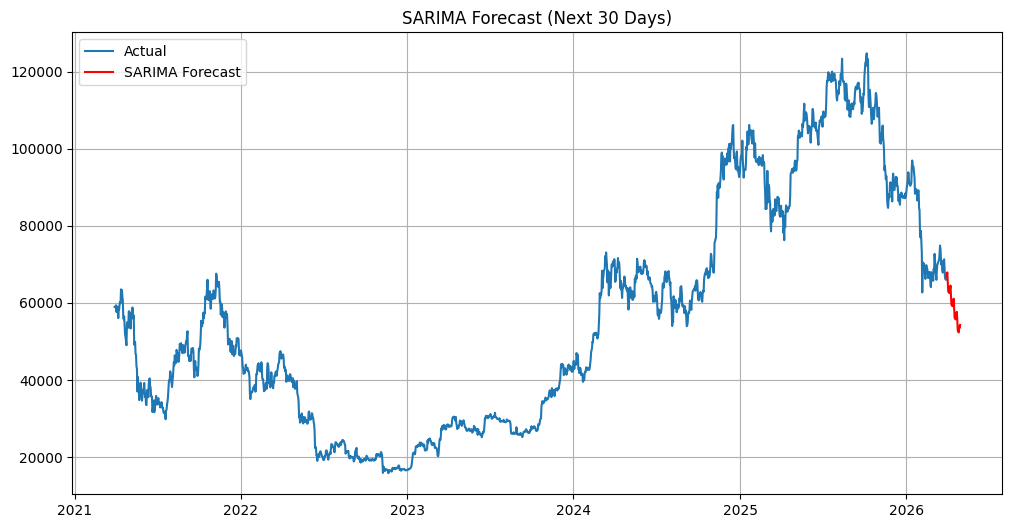

In [33]:
plt.figure(figsize=(12,6))

plt.plot(btc, label="Actual")
plt.plot(forecast, label="SARIMA Forecast", color='red')

plt.title("SARIMA Forecast (Next 30 Days)")
plt.legend()
plt.grid()
plt.show()